# Spectra quickstart

This notebook adapts the shipped Two Moons model to a new prior and compares it
with the unadapted model.  It runs on a CPU in a few minutes and needs no
reference posterior.

- Task: Two Moons, trained on a uniform prior over $[-1, 1]^2$.
- Model: `checkpoints/two_moons/model_0.pkl`.
- New prior: `strong_0`, a narrow isotropic Gaussian.  Its ratio to the
  training prior is a single exponential–quadratic factor, so Spectra transports
  the sampler exactly.
- One observation, 1000 samples from the base sampler and 1000 from Spectra.

In [1]:
import os
os.environ.setdefault("JAX_PLATFORMS", "cpu")

import sys
import time
from pathlib import Path

import jax
import matplotlib.pyplot as plt
import numpy as np

# Find the repository root, so the notebook works when opened from examples/.
REPO = Path.cwd().resolve()
while not (REPO / "spectra" / "__init__.py").is_file():
    if REPO.parent == REPO:
        raise RuntimeError("open this notebook from inside the Spectra repository")
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

from spectra import benchmark, e2e, hooks
from spectra.backbone import Backbone, load_checkpoint
from spectra.prior_shift import build_prior_shift
from spectra.simformer import upstream_nn
from spectra.transport import tq_target_score

## Prior and observation

`build_prior_shift` writes the ratio of the new prior to the training prior as
$\log r(\theta) = a^\top \theta - \tfrac{\kappa}{2}\lVert\theta\rVert^2 + \text{const}$.
For a Gaussian prior $N(\mu, \sigma^2 I)$ this gives $a = \mu / \sigma^2$ and
$\kappa = 1 / \sigma^2$.

In [2]:
TASK, PRIOR_TYPE, PRIOR_ID, OBS_SEED = "two_moons", "strong", 0, 1000000

prior = benchmark.load_prior_json(TASK, PRIOR_TYPE, PRIOR_ID)
theta_true, x_o = benchmark.load_observation(TASK, PRIOR_TYPE, PRIOR_ID, OBS_SEED)
shift = build_prior_shift(TASK, PRIOR_TYPE, PRIOR_ID)
eq = shift.expquad

print("new prior:    mu =", np.round(prior["mu"], 3), " sigma =", round(prior["sigma"][0], 3))
print("prior ratio:  a  =", np.round(eq.a, 3), " kappa =", round(eq.kappa, 3))
print("observation:  x_o =", np.round(np.asarray(x_o), 3))

new prior:    mu = [-0.297  0.456]  sigma = 0.115
prior ratio:  a  = [-22.255  34.231]  kappa = 75.0
observation:  x_o = [0.188 0.778]


## Model

The pretrained Simformer is frozen.  `Backbone` answers batched score queries
$s_p(\theta_t, t \mid x_o)$ against it.

In [3]:
ckpt = load_checkpoint(REPO / "checkpoints" / TASK / "model_0.pkl")
backbone = Backbone(ckpt, mode="conditional", nn=upstream_nn())

## Sampling

Every method is a hook `hook(z, t) -> (score, aux)` plugged into the same
reverse-SDE driver.  `make_base_hook` returns the pretrained score unchanged.
`make_tq_hook` returns the exactly transported score for the new prior.  Both
runs use 100 reverse steps without a Langevin corrector, and start from the same
terminal draw with the same Brownian increments, so they differ only in the
hook.

In [4]:
NUM_SAMPLES = 1000
cfg = e2e.SamplerConfig(num_steps=100, langevin_steps=0)

base_hook, _, _ = hooks.make_base_hook(backbone, x_o)
spectra_hook, _, _ = hooks.make_tq_hook(backbone, x_o, eq.a_jnp, eq.kappa)

k_init, k_noise = jax.random.split(jax.random.PRNGKey(0))
mean, std = backbone.terminal_moments()
x_init = e2e.draw_terminal(k_init, NUM_SAMPLES, mean, std)
diffusion_noise, langevin_noise = e2e.make_noise(
    k_noise, cfg.num_steps, NUM_SAMPLES, shift.theta_dim, cfg.langevin_steps)

samples = {}
for name, hook in [("Base", base_hook), ("Spectra", spectra_hook)]:
    t0 = time.perf_counter()
    res = e2e.reverse_sample(hook, schedule=backbone.schedule, cfg=cfg, x_init=x_init,
                             diffusion_noise=diffusion_noise,
                             langevin_noise=langevin_noise, snapshot_fracs=())
    samples[name] = np.asarray(res.samples)
    print(f"{name}: {NUM_SAMPLES} samples in {time.perf_counter() - t0:.1f} s "
          f"(compilation included)")

Base: 1000 samples in 7.1 s (compilation included)


Spectra: 1000 samples in 8.2 s (compilation included)


## Result

The base sampler targets the posterior under the training prior.  Spectra
targets the posterior under the new prior, whose contours are drawn in orange,
and keeps only the part of the base posterior that the new prior supports.

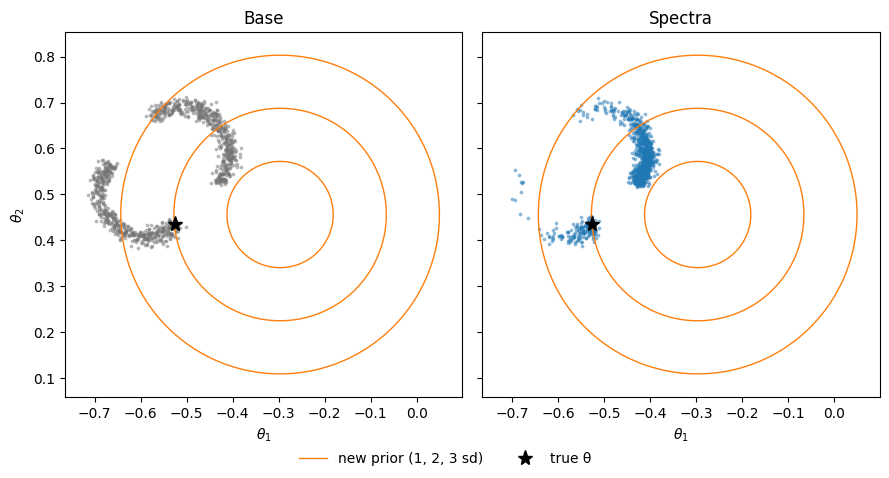

In [5]:
mu, sigma = np.asarray(prior["mu"]), prior["sigma"][0]
points = np.concatenate([samples["Base"], samples["Spectra"]])
lo = np.minimum(points.min(0), mu - 3 * sigma) - 0.05
hi = np.maximum(points.max(0), mu + 3 * sigma) + 0.05
X, Y = np.meshgrid(np.linspace(lo[0], hi[0], 300), np.linspace(lo[1], hi[1], 300))
prior_sd = np.hypot(X - mu[0], Y - mu[1]) / sigma

fig, axes = plt.subplots(1, 2, figsize=(9, 4.8), sharex=True, sharey=True)
for ax, (name, color) in zip(axes, [("Base", "0.45"), ("Spectra", "tab:blue")]):
    s = samples[name]
    ax.scatter(s[:, 0], s[:, 1], s=3, alpha=0.4, color=color)
    ax.contour(X, Y, prior_sd, levels=[1, 2, 3], colors="tab:orange", linewidths=1)
    ax.plot(*np.asarray(theta_true), marker="*", color="k", ms=11, ls="none")
    ax.set_title(name)
    ax.set_aspect("equal")
    ax.set_xlabel(r"$\theta_1$")
axes[0].set_xlim(lo[0], hi[0])
axes[0].set_ylim(lo[1], hi[1])
axes[0].set_ylabel(r"$\theta_2$")
fig.legend(handles=[
    plt.Line2D([], [], color="tab:orange", lw=1, label="new prior (1, 2, 3 sd)"),
    plt.Line2D([], [], color="k", marker="*", ms=11, ls="none", label="true θ")],
    loc="lower center", ncol=2, frameon=False)
fig.tight_layout(rect=(0, 0.07, 1, 1))
plt.show()

## Using your own score model

The transport needs nothing from the Simformer beyond its score.  Given a
function `score_fn(m, rho)` that returns the base posterior score at state `m`
and noise variance `rho` (with the observation already bound), Spectra's score
under the new prior at state `z` and noise variance `tau` is

```python
s, _ = tq_target_score(score_fn, z, tau, a, kappa)
```

which computes $D = 1 + \kappa\tau$, $m = (z + \tau a)/D$, $\rho = \tau/D$ and
$s = (a - \kappa z)/D + s_p(m, \rho)/D$.  That is the whole method for a single
factor.  The cell below checks that it gives the same score as the hook used
above.  The two agree up to float32 rounding, because the hook converts the
noise level to diffusion time in a slightly different way.

In [6]:
score_fn = lambda m, rho: backbone.score_theta_tau(m, rho, x_o)

# Noisy versions of the Spectra samples at five noise levels.
rng = np.random.default_rng(0)
for t in np.linspace(backbone.schedule.t_min, backbone.schedule.t_max, 5):
    tau = backbone.schedule.sigma(t) ** 2
    z = samples["Spectra"][:200] + np.sqrt(tau) * rng.standard_normal((200, 2))
    z = z.astype(np.float32)
    s_function, _ = tq_target_score(score_fn, z, tau, eq.a_jnp, eq.kappa)
    s_hook, _ = spectra_hook(z, t)
    rel = np.max(np.abs(s_function - s_hook)) / np.max(np.abs(s_hook))
    print(f"tau = {float(tau):.1e}   relative difference = {float(rel):.1e}")

tau = 1.0e-08   relative difference = 2.8e-06
tau = 3.9e-06   relative difference = 0.0e+00


tau = 1.5e-03   relative difference = 0.0e+00
tau = 5.8e-01   relative difference = 0.0e+00


tau = 2.2e+02   relative difference = 0.0e+00
